[*********************100%***********************]  6 of 6 completed


Date,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Avg Annual Return
Ticker,,,,,,,,,,,,,
SPY,+13.5%,+1.2%,+12.0%,+21.7%,-4.6%,+31.2%,+18.3%,+28.7%,-18.2%,+26.2%,+24.9%,+17.7%,+14.4%
QQQ,+19.2%,+9.4%,+7.1%,+32.7%,-0.1%,+39.0%,+48.4%,+27.4%,-32.6%,+54.9%,+25.6%,+20.8%,+21.0%
DIA,+9.7%,+0.1%,+16.4%,+28.1%,-3.7%,+25.0%,+9.6%,+20.8%,-7.0%,+16.0%,+14.8%,+14.7%,+12.0%
Broad Market Avg,+14.1%,+3.6%,+11.8%,+27.5%,-2.8%,+31.7%,+25.4%,+25.7%,-19.3%,+32.4%,+21.8%,+17.7%,+15.8%
VTV,+13.2%,-1.0%,+17.1%,+17.1%,-5.5%,+25.7%,+2.3%,+26.5%,-2.1%,+9.3%,+16.0%,+15.3%,+11.2%
MTUM,+14.6%,+8.9%,+5.0%,+37.5%,-1.7%,+27.3%,+29.9%,+13.4%,-18.3%,+9.1%,+32.9%,+22.1%,+15.1%
USMV,+16.3%,+5.4%,+10.6%,+18.9%,+1.3%,+27.7%,+5.6%,+20.8%,-9.4%,+10.3%,+15.7%,+7.6%,+10.9%
Smart Beta Avg,+14.7%,+4.5%,+10.9%,+24.5%,-1.9%,+26.9%,+12.6%,+20.2%,-9.9%,+9.6%,+21.5%,+15.0%,+12.4%


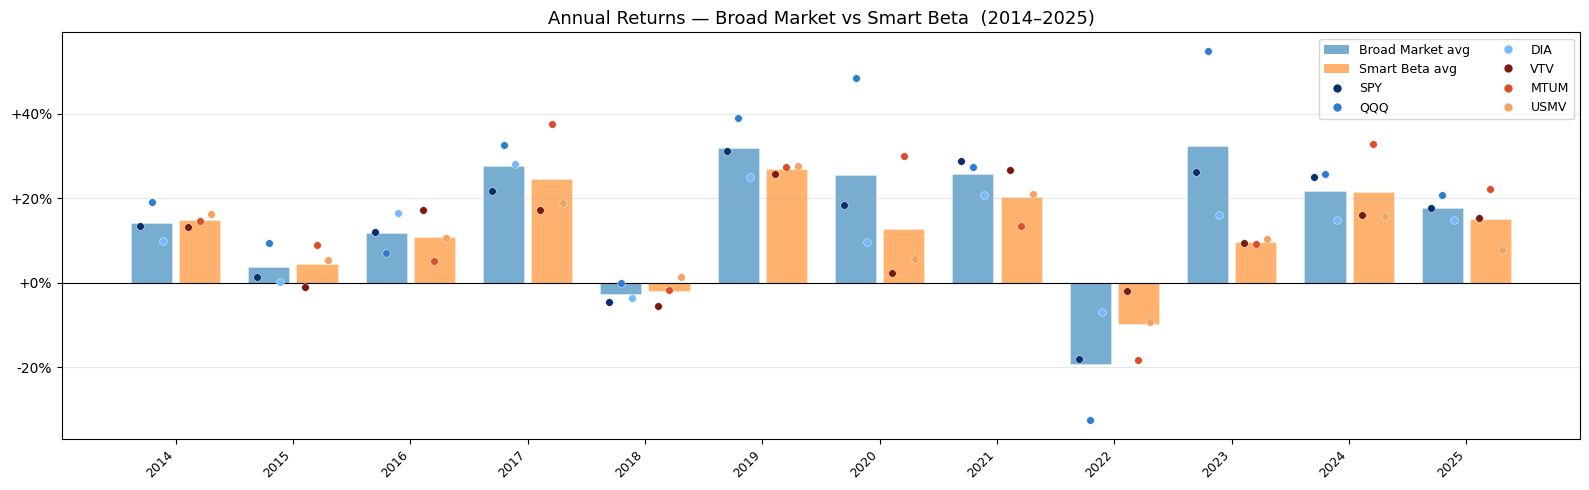

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from IPython.display import display

GROUPS = {
    "Broad Market": ["SPY", "QQQ", "DIA"],
    "Smart Beta":   ["VTV", "MTUM", "USMV"],
}
GROUP_COLORS = {"Broad Market": "#1f77b4", "Smart Beta": "#ff7f0e"}
TICKER_COLORS = {
    "SPY": "#0a2f6e", "QQQ": "#2d7dd2", "DIA": "#74b9ff",   # blue shades
    "VTV": "#7b1a0e", "MTUM": "#d94f2b", "USMV": "#f4a261", # red/orange shades
}

TICKERS = [t for tickers in GROUPS.values() for t in tickers]

# --- Data ---
prices = yf.download(TICKERS, period="max", auto_adjust=True)["Close"]
dr = prices.pct_change()
annual = ((1 + dr).groupby(dr.index.year).prod() - 1) * 100  # %

current_year = pd.Timestamp.today().year

def first_full_year(ticker):
    d = prices[ticker].dropna().index[0]
    return d.year if (d.month == 1 and d.day <= 5) else d.year + 1

shared_start = max(first_full_year(t) for t in TICKERS)
shared_years = [y for y in annual.index if shared_start <= y < current_year]

# --- Table: individual rows per ticker + bold group avg row ---
rows = {}
for group, tickers in GROUPS.items():
    for t in tickers:
        rows[t] = annual.loc[shared_years, t]
    rows[f"{group} Avg"] = annual.loc[shared_years, tickers].mean(axis=1)

tbl = pd.DataFrame(rows).T.round(1)
tbl.index.name = "Ticker"
year_cols = list(tbl.columns)
tbl["Avg Annual Return"] = tbl[year_cols].mean(axis=1).round(2)

avg_rows = [r for r in tbl.index if "Avg" in r]

def style_rows(row):
    if row.name in avg_rows:
        return ["font-weight: bold; border-top: 2px solid #888"] * len(row)
    return [""] * len(row)

styled = (
    tbl.style
    .format(lambda v: f"{v:+.1f}%")
    .background_gradient(cmap="RdYlGn", subset=year_cols, axis=None, vmin=-40, vmax=40)
    .apply(style_rows, axis=1)
    .set_caption(f"Annual Returns (%) — {shared_start}–{current_year - 1}")
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("margin-bottom", "6px")]}])
)
display(styled)

# --- Chart: 2 group bars + individual ticker dots ---
fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(shared_years))
width = 0.35
gap = 0.06

for gi, (group, tickers) in enumerate(GROUPS.items()):
    group_vals = annual.loc[shared_years, tickers].mean(axis=1).values
    bar_x = x + gi * (width + gap)
    ax.bar(bar_x, group_vals, width, color=GROUP_COLORS[group], alpha=0.6,
           edgecolor="white", linewidth=0.4)

    # Individual ticker dots with jitter inside the bar footprint
    jitter = np.linspace(-width * 0.28, width * 0.28, len(tickers))
    for ji, ticker in enumerate(tickers):
        vals = annual.loc[shared_years, ticker].values
        ax.scatter(bar_x + jitter[ji], vals, s=30, color=TICKER_COLORS[ticker],
                   zorder=4, edgecolors="white", linewidths=0.3)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x + (width + gap) / 2)
ax.set_xticklabels(shared_years, rotation=45, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
ax.set_title(f"Annual Returns — Broad Market vs Smart Beta  ({shared_start}–{current_year - 1})", fontsize=13)

legend_els = [
    Patch(facecolor=GROUP_COLORS["Broad Market"], alpha=0.6, label="Broad Market avg"),
    Patch(facecolor=GROUP_COLORS["Smart Beta"],   alpha=0.6, label="Smart Beta avg"),
] + [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=TICKER_COLORS[t],
           markersize=7, label=t)
    for t in TICKERS
]
ax.legend(handles=legend_els, fontsize=9, ncol=2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


[*********************100%***********************]  6 of 6 completed


,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Avg Annual Return
Ticker,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SPY,+0.4%,+38.0%,+22.5%,+33.5%,+28.7%,+20.4%,-9.7%,-11.8%,-21.6%,+28.2%,+10.7%,+4.8%,+15.8%,+5.1%,-36.8%,+26.4%,+15.1%,+1.9%,+16.0%,+32.3%,+13.5%,+1.2%,+12.0%,+21.7%,-4.6%,+31.2%,+18.3%,+28.7%,-18.2%,+26.2%,+24.9%,+17.7%,+12.3%
QQQ,—,—,—,—,—,—,-36.1%,-33.3%,-37.4%,+49.7%,+10.5%,+1.6%,+7.1%,+19.0%,-41.7%,+54.7%,+20.1%,+3.5%,+18.1%,+36.6%,+19.2%,+9.4%,+7.1%,+32.7%,-0.1%,+39.0%,+48.4%,+27.4%,-32.6%,+54.9%,+25.6%,+20.8%,+12.5%
DIA,—,—,—,—,—,+27.7%,-6.0%,-5.0%,-14.7%,+27.9%,+5.0%,+1.6%,+18.9%,+8.8%,-32.1%,+22.7%,+14.0%,+8.1%,+9.9%,+29.6%,+9.7%,+0.1%,+16.4%,+28.1%,-3.7%,+25.0%,+9.6%,+20.8%,-7.0%,+16.0%,+14.8%,+14.7%,+9.7%
Broad Market Avg,+0.4%,+38.0%,+22.5%,+33.5%,+28.7%,+24.1%,-17.3%,-16.7%,-24.5%,+35.3%,+8.8%,+2.7%,+14.0%,+11.0%,-36.9%,+34.6%,+16.4%,+4.5%,+14.7%,+32.9%,+14.1%,+3.6%,+11.8%,+27.5%,-2.8%,+31.7%,+25.4%,+25.7%,-19.3%,+32.4%,+21.8%,+17.7%,+13.0%
VTV,—,—,—,—,—,—,—,—,—,—,—,+7.2%,+22.4%,-0.1%,-35.9%,+19.9%,+14.5%,+1.1%,+15.2%,+33.1%,+13.2%,-1.0%,+17.1%,+17.1%,-5.5%,+25.7%,+2.3%,+26.5%,-2.1%,+9.3%,+16.0%,+15.3%,+10.1%
MTUM,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,+14.6%,+8.9%,+5.0%,+37.5%,-1.7%,+27.3%,+29.9%,+13.4%,-18.3%,+9.1%,+32.9%,+22.1%,+15.1%
USMV,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,+10.8%,+25.1%,+16.3%,+5.4%,+10.6%,+18.9%,+1.3%,+27.7%,+5.6%,+20.8%,-9.4%,+10.3%,+15.7%,+7.6%,+11.9%
Smart Beta Avg,—,—,—,—,—,—,—,—,—,—,—,+7.2%,+22.4%,-0.1%,-35.9%,+19.9%,+14.5%,+1.1%,+13.0%,+29.1%,+14.7%,+4.5%,+10.9%,+24.5%,-1.9%,+26.9%,+12.6%,+20.2%,-9.9%,+9.6%,+21.5%,+15.0%,+10.5%


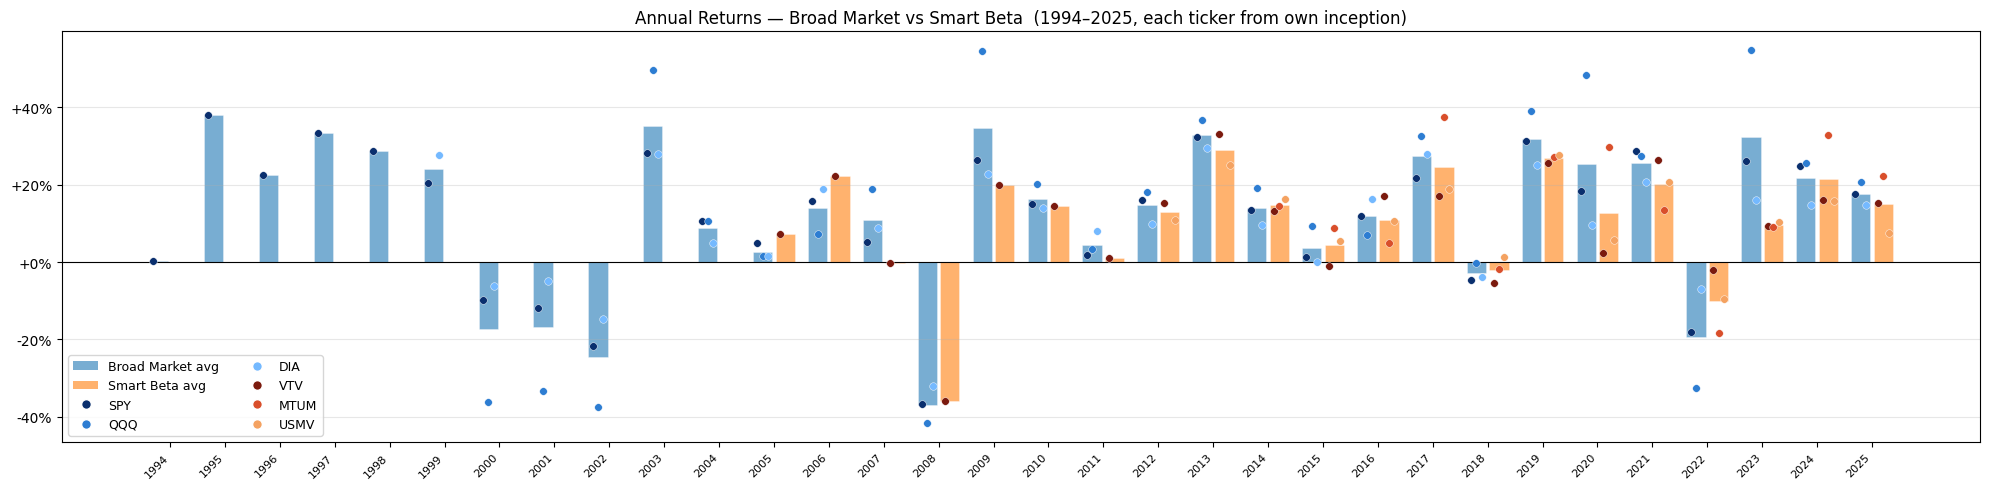

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from IPython.display import display

GROUPS = {
    "Broad Market": ["SPY", "QQQ", "DIA"],
    "Smart Beta":   ["VTV", "MTUM", "USMV"],
}
GROUP_COLORS = {"Broad Market": "#1f77b4", "Smart Beta": "#ff7f0e"}
TICKER_COLORS = {
    "SPY": "#0a2f6e", "QQQ": "#2d7dd2", "DIA": "#74b9ff",
    "VTV": "#7b1a0e", "MTUM": "#d94f2b", "USMV": "#f4a261",
}

TICKERS = [t for tickers in GROUPS.values() for t in tickers]

# --- Data ---
prices = yf.download(TICKERS, period="max", auto_adjust=True)["Close"]
dr = prices.pct_change()
annual = ((1 + dr).groupby(dr.index.year).prod() - 1) * 100  # %

current_year = pd.Timestamp.today().year

def first_full_year(ticker):
    d = prices[ticker].dropna().index[0]
    return d.year if (d.month == 1 and d.day <= 5) else d.year + 1

# Anchor on the first-listed ticker (SPY); other tickers are NaN before their own inception
anchor_start = first_full_year(TICKERS[0])
all_years = [y for y in annual.index if anchor_start <= y < current_year]

# --- Build rows with NaN for pre-inception years ---
rows = {}
for group, tickers in GROUPS.items():
    for t in tickers:
        s = pd.Series(index=all_years, dtype=float)
        t_start = first_full_year(t)
        avail = [y for y in all_years if y >= t_start]
        s[avail] = annual.loc[avail, t].values
        rows[t] = s
    # Group avg: mean of whichever tickers have data that year (NaN-aware)
    group_df = pd.DataFrame({t: rows[t] for t in tickers})
    rows[f"{group} Avg"] = group_df.mean(axis=1)  # skipna=True by default

tbl = pd.DataFrame(rows).T.round(1)
tbl.index.name = "Ticker"
year_cols = list(tbl.columns)
tbl["Avg Annual Return"] = tbl[year_cols].mean(axis=1, skipna=True).round(2)

avg_rows = [r for r in tbl.index if "Avg" in r]

def style_rows(row):
    if row.name in avg_rows:
        return ["font-weight: bold; border-top: 2px solid #888"] * len(row)
    return [""] * len(row)

styled = (
    tbl.style
    .format(lambda v: f"{v:+.1f}%" if pd.notna(v) else "—")
    .background_gradient(cmap="RdYlGn", subset=year_cols, axis=None, vmin=-40, vmax=40)
    .apply(style_rows, axis=1)
    .set_caption(f"Annual Returns (%) — each ticker from its own inception  (anchor: {TICKERS[0]} from {anchor_start})")
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("margin-bottom", "6px")]}])
)
display(styled)

# --- Chart: group avg bars (NaN-aware) + individual dots ---
fig, ax = plt.subplots(figsize=(20, 5))
x = np.arange(len(all_years))
width = 0.35
gap = 0.06

for gi, (group, tickers) in enumerate(GROUPS.items()):
    group_df = pd.DataFrame({t: rows[t] for t in tickers})
    group_avg = group_df.mean(axis=1)  # NaN-aware
    bar_x = x + gi * (width + gap)

    # Only draw bar where at least one ticker has data
    for xi, yr in enumerate(all_years):
        val = group_avg.loc[yr]
        if pd.notna(val):
            ax.bar(bar_x[xi], val, width, color=GROUP_COLORS[group], alpha=0.6,
                   edgecolor="white", linewidth=0.4)

    # Individual ticker dots
    jitter = np.linspace(-width * 0.28, width * 0.28, len(tickers))
    for ji, ticker in enumerate(tickers):
        for xi, yr in enumerate(all_years):
            val = rows[ticker].loc[yr]
            if pd.notna(val):
                ax.scatter(bar_x[xi] + jitter[ji], val, s=30,
                           color=TICKER_COLORS[ticker], zorder=4,
                           edgecolors="white", linewidths=0.3)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x + (width + gap) / 2)
ax.set_xticklabels(all_years, rotation=45, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
ax.set_title(f"Annual Returns — Broad Market vs Smart Beta  ({anchor_start}–{current_year - 1}, each ticker from own inception)", fontsize=12)

legend_els = [
    Patch(facecolor=GROUP_COLORS["Broad Market"], alpha=0.6, label="Broad Market avg"),
    Patch(facecolor=GROUP_COLORS["Smart Beta"],   alpha=0.6, label="Smart Beta avg"),
] + [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=TICKER_COLORS[t],
           markersize=7, label=t)
    for t in TICKERS
]
ax.legend(handles=legend_els, fontsize=9, ncol=2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
